# Data Assimilation in eWaterCycle using BMI
## Ensemble Kalman Filter example using Lorenz-96 model
The Ensemble Kalman Filter (EnKF) is a variant on the Kalman Filter when dealing with models for which it is hard to define a tangiant model. Data Assimilation methods, including all variants of the Kalman Filter Family, set to provide the (mathimatically) optimal estimation of the true state of a system, given that a (often phyiscal/physially based) model is available that can project the current state of the model into the future and that at the same time observations are available that measure (parts of) the state, either directly or indirectly.

A mathematical overview of the EnKF is given in [cite Evensen]. This notebook is intended as an introduction on how to do data assimilation within the eWaterCycle framework, with models that communicate through BMI. It is not intended as an indepth explenation of the EnKF.

## data assimilation jargon
The following terms are often used in data assimilation:

- **ensemble** is a collection of model-instances. Often these are multiple instances of the same model where the spread in the model state represents the uncertainty in our knowledge of that model state.
- **model** a mathematical and/or computer code represenation of how the state of the system evolves in time.  
- **observation** a measurement (or set of measurements, including images)that relate to (part of) the state of the system
- **observation model** a mathematical and/or computer code representation of how the state relates to the observations. Often donated by $\mathbf{H}$.
- **forecast** The forecasted state using the model and a previous state
- **analyses** The best estimate of the state using both a forecast and an observation. The analyses (or analyses-ensemble) is the output of a data assimilation method.

In this notebook I will use a Lorenz-96 model that has been wrapped with BMI, see the 'Lorenz-96 model ensemble demonstration' notebook in this repository for an introduction into that model. I use the Ensemble Kalman Filter as data assimilation method, see [cite Evensen]. The focus of this notebook is to demonstrate how to do a data assimilation experiment where the model and the method are not part of the experiment code.

The experiment I run is a comparison of the bias of the ensemble mean versus the truth and of the spread of the ensemble over time. The Truth is generated through a model instance classified as "true" and the ensemble starts as slight modifications of this truth, which after a spin-up period, significantly deviate from the truth. The observations are direct measurements of part of the state, with added measurement noise.

The first cell loads all the needed dependencies. The final two are the model and the data assimilation method and are shared with this repository.


In [ ]:
!pip install numpy pandas matplotlib pyyaml

In [ ]:
#required libraries and settings
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
import io
import math

import BMILorenz
import EnKF

ModuleNotFoundError: No module named 'BMILorenz'

## settings
The settings for this experiment are split between settings for the model, for the observations and for the data assimilation method and finally for the experiment

In [ ]:
##model

J = 40 #dimension of Lorenz-96 Model
commonStartState = np.zeros(J) #start-vector
commonStartState[5]=0.01

#settings data in dict for export to YAML file
settings = {'J': J,
            'F': 8.0,
            'startTime': 0.0,
            'endTime': 10.0,
            'dt':1e-3,
            'startState': commonStartState}



##Observations
observationSigma = 0.05             #standard deviation of the observations
obsVector = range(math.floor(J/2))  #only observe half of the state
obsSize = len(obsVector);           #size of the observations vector
def H(state):                       #the "observation model" that links model-space to observation-space
    return state[obsVector]


##Ensemble Kalman Filter
N = 100                             #numeber of ensemble members, needs to be higher than dimension of the
                                    # model for stability, since no inflation is implemented.

## Experiment
spinUpTime = 3                      #time that the ensemble is run before data assimilation starts to
updateInterval = 1                  #how often is the ensemble updated with observations

plotState = 5                       #which state of the model (both truth and ensemble) to plot
obsPlotState = 5                    #which state of the observations to plot

In [ ]:
# Write YAML setting file for BMI model
with io.open('settings.yaml', 'w', encoding='utf8') as outfile:
    yaml.dump(settings, outfile, default_flow_style=False, allow_unicode=True)

In [ ]:
#start with  an empty ensemble
ensemble = []


#create and initialize an instance of the BMILorenz class
truthModel = BMILorenz.BMILorenz ()
truthModel.initialize('settings.yaml')

output = pd.DataFrame(columns = ['truth','observation'])

for n in range (N):
    #add an ensemble methods
    ensemble.append(BMILorenz.BMILorenz ())
    ensemble[n].initialize('settings.yaml')
    ensemble[n].set_value_at_indices('state',5,ensemble[n].get_value_at_indices('state',5) + np.random.randn(1)*0.01)

    #also add a column to the output dataframe to store the output
    output['ensemble' + str(n)]= np.nan



In [ ]:
#spin up the Ensemble.

while truthModel.get_current_time()< spinUpTime:

    truthModel.update()
    output.loc[truthModel.get_current_time(),'truth'] = truthModel.get_value_at_indices('state',plotState)

    observation = truthModel.get_value('state') + observationSigma * np.random.randn(J)
    output.at[truthModel.get_current_time(),'observation'] = observation[plotState]

    #loop through the ensemble members and store the state after each update
    for n in range (N):
        ensemble[n].update()
        output.at[ensemble[n].get_current_time(),'ensemble' + str(n)] = ensemble[n].get_value_at_indices('state',plotState)

    #TODO update observation on bases of observation

    #TODO track statistics metrics

updateTime = spinUpTime


In [ ]:
#run

foreCastEnsemble = np.zeros([J,N])
observationEnsemble = np.zeros([obsSize,N])

while truthModel.get_current_time()<truthModel.get_end_time():
    truthModel.update()
    output.loc[truthModel.get_current_time(),'truth'] = truthModel.get_value_at_indices('state',plotState)

    observation = H(truthModel.get_value('state')) + observationSigma * np.random.randn(obsSize)
    output.at[truthModel.get_current_time(),'observation'] = observation[plotState]



    #loop through the ensemble members and store the state after each update
    for n in range (N):
        ensemble[n].update()
        foreCastEnsemble[:,n] = ensemble[n].get_value('state')
        observationEnsemble[:,n] = observation + observationSigma*np.random.randn(obsSize)
        output.at[ensemble[n].get_current_time(),'ensemble' + str(n)] = ensemble[n].get_value_at_indices('state',plotState)

    #TODO update ensemble on bases of observation
    if truthModel.get_current_time() > updateTime:
        updateTime = updateTime + updateInterval
        analysesEnsemble = EnKF.EnKF(foreCastEnsemble,observationEnsemble,H)
        np.clip(analysesEnsemble, -10, 20, out=analysesEnsemble)

        for n in range (N):
            ensemble[n].set_value('state',analysesEnsemble[:,n])


    #TODO track statistics metrics


In [ ]:
plt.plot(output.loc[:,'ensemble0':],'k')
plt.plot(output.loc[:,'observation'],'r')
plt.plot(output.loc[:,'truth'],'g')

plt.show()

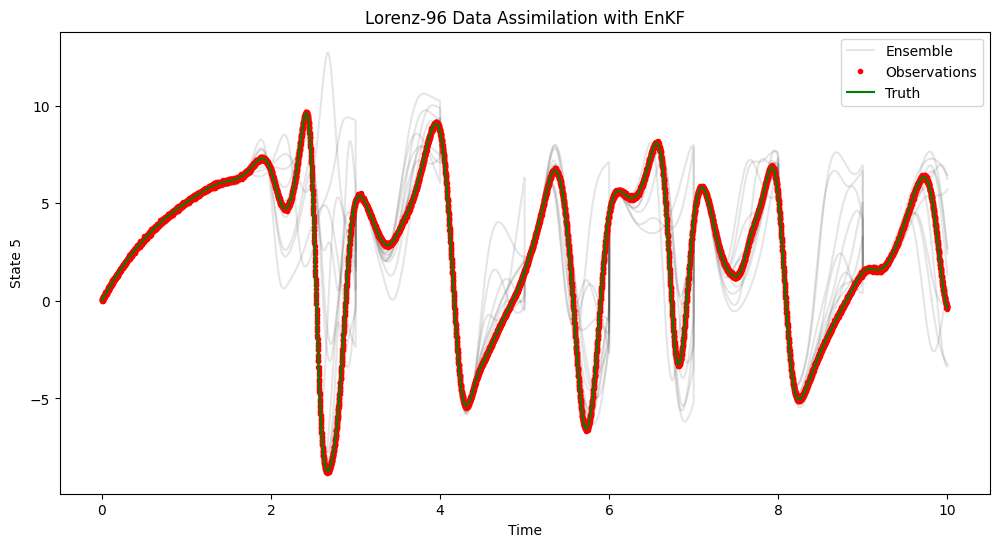

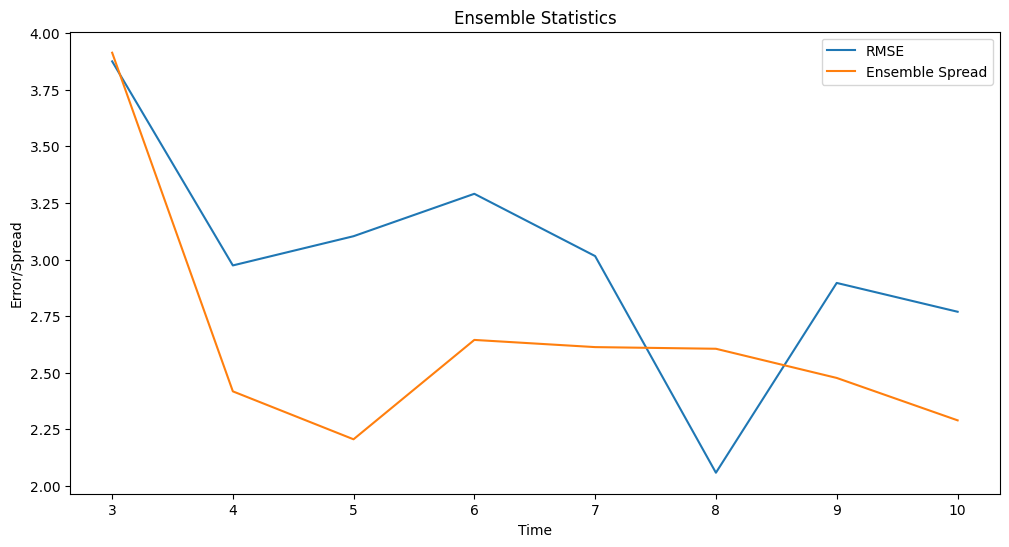

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
import io
import math

# Lorenz-96 model implementation
class Lorenz96:
    def __init__(self):
        self.J = None
        self.F = None
        self.dt = None
        self.state = None
        self.time = 0.0
        self.end_time = None

    def initialize(self, settings_file):
        with open(settings_file, 'r') as f:
            settings = yaml.safe_load(f)
        self.J = settings['J']
        self.F = settings['F']
        self.dt = settings['dt']
        self.end_time = settings['endTime']
        self.state = np.array(settings['startState'], dtype=float)
        self.time = settings['startTime']

    def update(self):
        # Lorenz-96 model: dx_i/dt = (x_{i+1} - x_{i-2}) * x_{i-1} - x_i + F
        x = self.state
        x_next = np.zeros_like(x)
        for i in range(self.J):
            x_next[i] = x[i] + self.dt * (
                (x[(i + 1) % self.J] - x[(i - 2) % self.J]) * x[(i - 1) % self.J] - x[i] + self.F
            )
        self.state = x_next
        self.time += self.dt

    def get_value(self, var_name):
        if var_name == 'state':
            return self.state
        raise ValueError(f"Unknown variable: {var_name}")

    def set_value(self, var_name, value):
        if var_name == 'state':
            self.state = value
        else:
            raise ValueError(f"Unknown variable: {var_name}")

    def get_value_at_indices(self, var_name, indices):
        if var_name == 'state':
            return self.state[indices]
        raise ValueError(f"Unknown variable: {var_name}")

    def set_value_at_indices(self, var_name, indices, value):
        if var_name == 'state':
            self.state[indices] = value
        else:
            raise ValueError(f"Unknown variable: {var_name}")

    def get_current_time(self):
        return self.time

    def get_end_time(self):
        return self.end_time

# Ensemble Kalman Filter implementation
def ensemble_kalman_filter(forecast_ensemble, observation_ensemble, H_func, R):
    """
    Perform EnKF update.
    forecast_ensemble: (state_dim, N) array of ensemble forecasts
    observation_ensemble: (obs_dim, N) array of perturbed observations
    H_func: observation operator function
    R: observation error covariance matrix
    Returns: analysis_ensemble (state_dim, N)
    """
    N = forecast_ensemble.shape[1]
    state_dim = forecast_ensemble.shape[0]
    obs_dim = observation_ensemble.shape[0]

    # Compute ensemble mean and perturbations
    X_f_mean = np.mean(forecast_ensemble, axis=1, keepdims=True)
    X_f_pert = forecast_ensemble - X_f_mean

    # Apply observation operator to forecast ensemble
    HX_f = np.array([H_func(forecast_ensemble[:, i]) for i in range(N)]).T  # (obs_dim, N)
    HX_f_mean = np.mean(HX_f, axis=1, keepdims=True)
    HX_f_pert = HX_f - HX_f_mean

    # Compute Kalman gain
    P_f = (1 / (N - 1)) * np.dot(HX_f_pert, HX_f_pert.T)  # Forecast error covariance in observation space
    K = np.dot(X_f_pert, HX_f_pert.T) / (N - 1) @ np.linalg.inv(P_f + R)

    # Update each ensemble member
    analysis_ensemble = np.zeros_like(forecast_ensemble)
    for n in range(N):
        y_n = observation_ensemble[:, n]
        analysis_ensemble[:, n] = (
            forecast_ensemble[:, n] + K @ (y_n - H_func(forecast_ensemble[:, n]))
        )

    return analysis_ensemble

# Settings
J = 40  # Dimension of Lorenz-96 Model
commonStartState = np.zeros(J)  # Start vector
commonStartState[5] = 0.01

# Model settings in dict for export to YAML file
settings = {
    'J': J,
    'F': 8.0,
    'startTime': 0.0,
    'endTime': 10.0,
    'dt': 1e-3,
    'startState': commonStartState.tolist()
}

# Observations
observationSigma = 0.05  # Standard deviation of the observations
obsVector = list(range(math.floor(J / 2)))  # Only observe half of the state
obsSize = len(obsVector)  # Size of the observations vector

def H(state):
    """Observation model that links model-space to observation-space"""
    return state[obsVector]

# Observation error covariance matrix
R = observationSigma**2 * np.eye(obsSize)

# Ensemble Kalman Filter
N = 100  # Number of ensemble members

# Experiment
spinUpTime = 3  # Time before data assimilation starts
updateInterval = 1  # How often to update with observations
plotState = 5  # State to plot for model
obsPlotState = 5  # State to plot for observations

# Write YAML settings file
with open('settings.yaml', 'w', encoding='utf8') as outfile:
    yaml.dump(settings, outfile, default_flow_style=False, allow_unicode=True)

# Initialize truth model and ensemble
truthModel = Lorenz96()
truthModel.initialize('settings.yaml')

# Pre-allocate output DataFrame with all ensemble columns
output_columns = ['truth', 'observation'] + [f'ensemble{n}' for n in range(N)]
output = pd.DataFrame(columns=output_columns, index=np.arange(0, settings['endTime'] + settings['dt'], settings['dt']))
output.index.name = 'time'

ensemble = []
for n in range(N):
    model = Lorenz96()
    model.initialize('settings.yaml')
    current_state = model.get_value_at_indices('state', 5)
    model.set_value_at_indices('state', 5, current_state + np.random.randn() * 0.01)
    ensemble.append(model)

# Spin-up phase
while truthModel.get_current_time() < spinUpTime:
    truthModel.update()
    t = truthModel.get_current_time()
    output.at[t, 'truth'] = truthModel.get_value_at_indices('state', plotState)

    observation = truthModel.get_value('state') + observationSigma * np.random.randn(J)
    output.at[t, 'observation'] = observation[obsPlotState]

    for n in range(N):
        ensemble[n].update()
        output.at[ensemble[n].get_current_time(), f'ensemble{n}'] = ensemble[n].get_value_at_indices('state', plotState)

# Main assimilation loop
updateTime = spinUpTime
forecast_ensemble = np.zeros((J, N))
observation_ensemble = np.zeros((obsSize, N))

# Pre-allocate lists for statistics at update intervals
update_times = []
rmse = []
ensemble_spread = []

while truthModel.get_current_time() < truthModel.get_end_time():
    truthModel.update()
    t = truthModel.get_current_time()
    output.at[t, 'truth'] = truthModel.get_value_at_indices('state', plotState)

    observation = H(truthModel.get_value('state')) + observationSigma * np.random.randn(obsSize)
    output.at[t, 'observation'] = observation[obsPlotState]

    # Update ensemble and compute forecast
    for n in range(N):
        ensemble[n].update()
        forecast_ensemble[:, n] = ensemble[n].get_value('state')
        observation_ensemble[:, n] = observation + observationSigma * np.random.randn(obsSize)
        output.at[ensemble[n].get_current_time(), f'ensemble{n}'] = ensemble[n].get_value_at_indices('state', plotState)

    # Compute statistics at update intervals
    if truthModel.get_current_time() >= updateTime:
        updateTime += updateInterval
        update_times.append(t)
        analyses_ensemble = ensemble_kalman_filter(forecast_ensemble, observation_ensemble, H, R)
        np.clip(analyses_ensemble, -10, 20, out=analyses_ensemble)

        for n in range(N):
            ensemble[n].set_value('state', analyses_ensemble[:, n])

        ensemble_mean = np.mean(forecast_ensemble, axis=1)
        true_state = truthModel.get_value('state')
        rmse.append(np.sqrt(np.mean((ensemble_mean - true_state) ** 2)))
        spread = np.std(forecast_ensemble, axis=1).mean()
        ensemble_spread.append(spread)

# Plot results
plt.figure(figsize=(12, 6))
for n in range(min(10, N)):  # Plot a subset of ensemble members for clarity
    plt.plot(output.index, output[f'ensemble{n}'], 'k', alpha=0.1, label='Ensemble' if n == 0 else None)
plt.plot(output.index, output['observation'], 'r.', label='Observations')
plt.plot(output.index, output['truth'], 'g-', label='Truth')
plt.xlabel('Time')
plt.ylabel(f'State {plotState}')
plt.title('Lorenz-96 Data Assimilation with EnKF')
plt.legend()
plt.show()

# Plot RMSE and ensemble spread
plt.figure(figsize=(12, 6))
plt.plot(update_times, rmse, label='RMSE')
plt.plot(update_times, ensemble_spread, label='Ensemble Spread')
plt.xlabel('Time')
plt.ylabel('Error/Spread')
plt.title('Ensemble Statistics')
plt.legend()
plt.show()

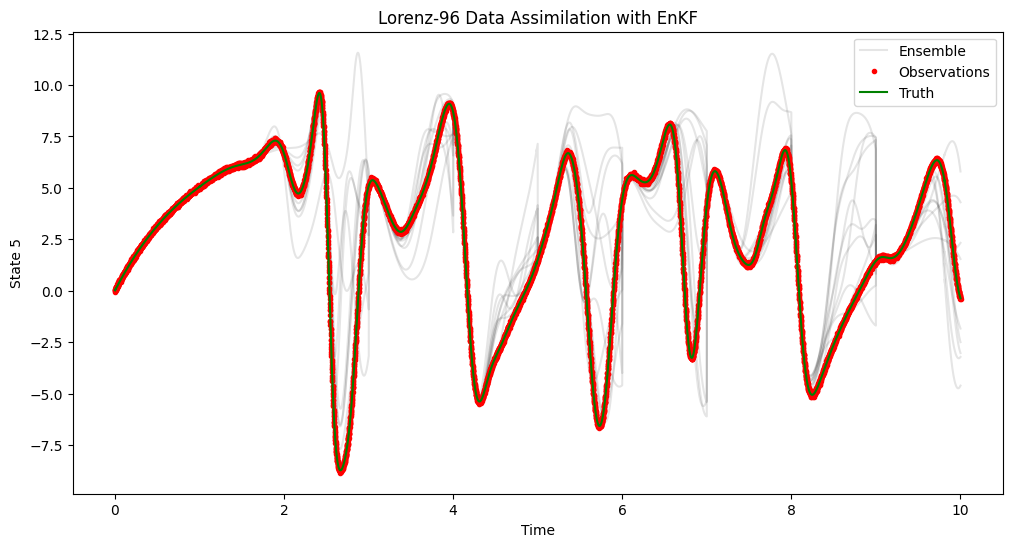

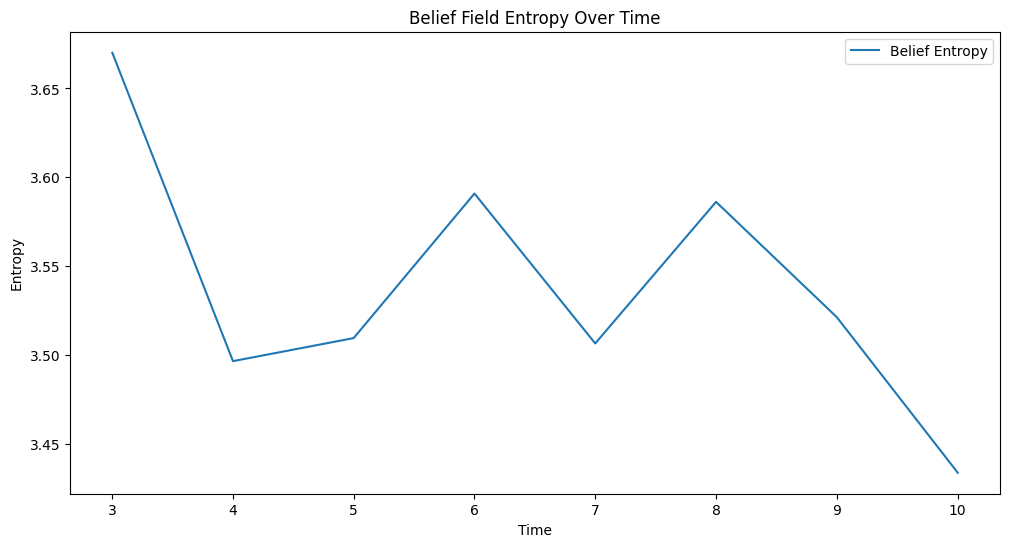

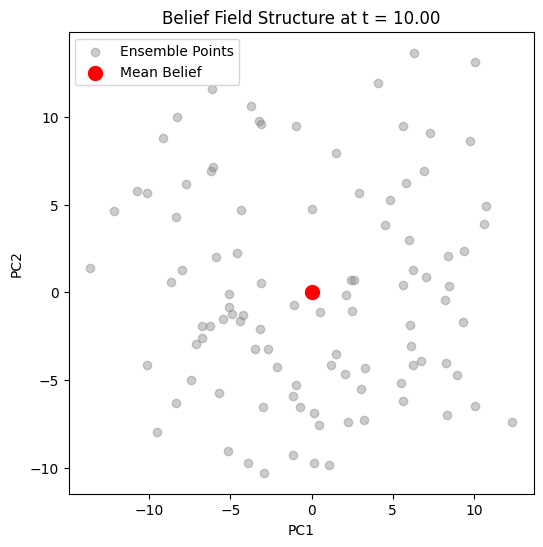

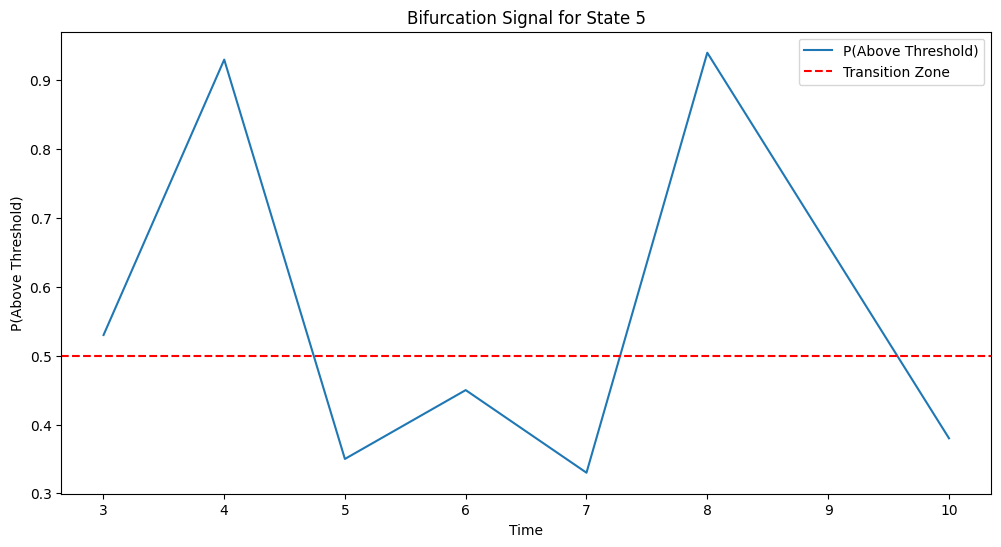

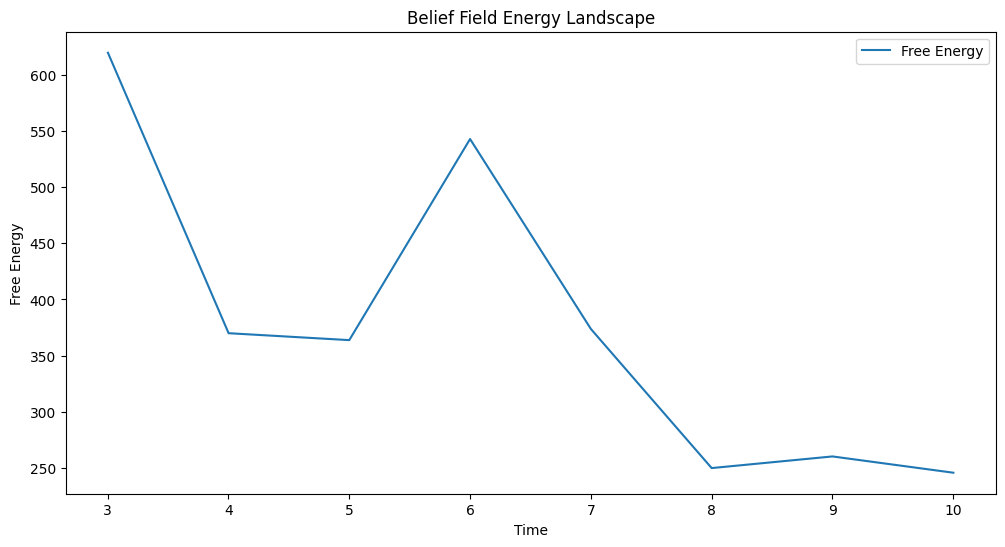

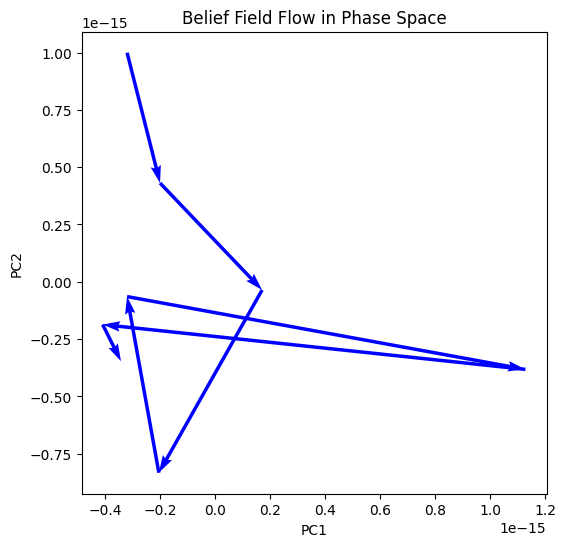

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
import io
import math
from scipy.stats import entropy
from sklearn.decomposition import PCA
from matplotlib.quiver import Quiver

# Lorenz-96 model implementation
class Lorenz96:
    def __init__(self):
        self.J = None
        self.F = None
        self.dt = None
        self.state = None
        self.time = 0.0
        self.end_time = None

    def initialize(self, settings_file):
        with open(settings_file, 'r') as f:
            settings = yaml.safe_load(f)
        self.J = settings['J']
        self.F = settings['F']
        self.dt = settings['dt']
        self.end_time = settings['endTime']
        self.state = np.array(settings['startState'], dtype=float)
        self.time = settings['startTime']

    def update(self):
        x = self.state
        x_next = np.zeros_like(x)
        for i in range(self.J):
            x_next[i] = x[i] + self.dt * (
                (x[(i + 1) % self.J] - x[(i - 2) % self.J]) * x[(i - 1) % self.J] - x[i] + self.F
            )
        self.state = x_next
        self.time += self.dt

    def get_value(self, var_name):
        if var_name == 'state':
            return self.state
        raise ValueError(f"Unknown variable: {var_name}")

    def set_value(self, var_name, value):
        if var_name == 'state':
            self.state = value
        else:
            raise ValueError(f"Unknown variable: {var_name}")

    def get_value_at_indices(self, var_name, indices):
        if var_name == 'state':
            return self.state[indices]
        raise ValueError(f"Unknown variable: {var_name}")

    def set_value_at_indices(self, var_name, indices, value):
        if var_name == 'state':
            self.state[indices] = value
        else:
            raise ValueError(f"Unknown variable: {var_name}")

    def get_current_time(self):
        return self.time

    def get_end_time(self):
        return self.end_time

# Ensemble Kalman Filter implementation
def ensemble_kalman_filter(forecast_ensemble, observation_ensemble, H_func, R):
    N = forecast_ensemble.shape[1]
    state_dim = forecast_ensemble.shape[0]
    obs_dim = observation_ensemble.shape[0]

    X_f_mean = np.mean(forecast_ensemble, axis=1, keepdims=True)
    X_f_pert = forecast_ensemble - X_f_mean

    HX_f = np.array([H_func(forecast_ensemble[:, i]) for i in range(N)]).T
    HX_f_mean = np.mean(HX_f, axis=1, keepdims=True)
    HX_f_pert = HX_f - HX_f_mean

    P_f = (1 / (N - 1)) * np.dot(HX_f_pert, HX_f_pert.T)
    K = np.dot(X_f_pert, HX_f_pert.T) / (N - 1) @ np.linalg.inv(P_f + R)

    analysis_ensemble = np.zeros_like(forecast_ensemble)
    for n in range(N):
        y_n = observation_ensemble[:, n]
        analysis_ensemble[:, n] = forecast_ensemble[:, n] + K @ (y_n - H_func(forecast_ensemble[:, n]))

    return analysis_ensemble

# Settings
J = 40  # Dimension of Lorenz-96 Model
commonStartState = np.zeros(J)
commonStartState[5] = 0.01

settings = {
    'J': J,
    'F': 8.0,
    'startTime': 0.0,
    'endTime': 10.0,
    'dt': 1e-3,
    'startState': commonStartState.tolist()
}

# Observations
observationSigma = 0.05
obsVector = list(range(math.floor(J / 2)))
obsSize = len(obsVector)

def H(state):
    return state[obsVector]

R = observationSigma**2 * np.eye(obsSize)

# Ensemble Kalman Filter
N = 100

# Experiment
spinUpTime = 3
updateInterval = 1
plotState = 5
obsPlotState = 5

# Write YAML settings file
with open('settings.yaml', 'w', encoding='utf8') as outfile:
    yaml.dump(settings, outfile, default_flow_style=False, allow_unicode=True)

# Initialize truth model and ensemble
truthModel = Lorenz96()
truthModel.initialize('settings.yaml')

output_columns = ['truth', 'observation'] + [f'ensemble{n}' for n in range(N)]
output = pd.DataFrame(columns=output_columns, index=np.arange(0, settings['endTime'] + settings['dt'], settings['dt']))
output.index.name = 'time'

ensemble = []
for n in range(N):
    model = Lorenz96()
    model.initialize('settings.yaml')
    current_state = model.get_value_at_indices('state', 5)
    model.set_value_at_indices('state', 5, current_state + np.random.randn() * 0.01)
    ensemble.append(model)

# Spin-up phase
while truthModel.get_current_time() < spinUpTime:
    truthModel.update()
    t = truthModel.get_current_time()
    output.at[t, 'truth'] = truthModel.get_value_at_indices('state', plotState)

    observation = truthModel.get_value('state') + observationSigma * np.random.randn(J)
    output.at[t, 'observation'] = observation[obsPlotState]

    for n in range(N):
        ensemble[n].update()
        output.at[ensemble[n].get_current_time(), f'ensemble{n}'] = ensemble[n].get_value_at_indices('state', plotState)

# Main assimilation loop
updateTime = spinUpTime
forecast_ensemble = np.zeros((J, N))
observation_ensemble = np.zeros((obsSize, N))

# PFT-enhanced metrics
ensemble_entropy = []
p_right_lobe = []
free_energy_trace = []
pca_centers = []

while truthModel.get_current_time() < truthModel.get_end_time():
    truthModel.update()
    t = truthModel.get_current_time()
    output.at[t, 'truth'] = truthModel.get_value_at_indices('state', plotState)

    observation = H(truthModel.get_value('state')) + observationSigma * np.random.randn(obsSize)
    output.at[t, 'observation'] = observation[obsPlotState]

    # Update ensemble and compute forecast
    for n in range(N):
        ensemble[n].update()
        forecast_ensemble[:, n] = ensemble[n].get_value('state')
        observation_ensemble[:, n] = observation + observationSigma * np.random.randn(obsSize)
        output.at[ensemble[n].get_current_time(), f'ensemble{n}'] = ensemble[n].get_value_at_indices('state', plotState)

    # PFT analysis at update intervals
    if truthModel.get_current_time() >= updateTime:
        updateTime += updateInterval
        true_state = truthModel.get_value('state')
        analyses_ensemble = ensemble_kalman_filter(forecast_ensemble, observation_ensemble, H, R)
        np.clip(analyses_ensemble, -10, 20, out=analyses_ensemble)

        for n in range(N):
            ensemble[n].set_value('state', analyses_ensemble[:, n])

        # 1. Belief Field Evolution
        ensemble_mean = np.mean(forecast_ensemble, axis=1)
        ensemble_std = np.std(forecast_ensemble, axis=1)
        entropy_estimate = entropy(np.abs(ensemble_std) + 1e-6)
        ensemble_entropy.append(entropy_estimate)

        # 2. Field Coherence via PCA
        pca = PCA(n_components=2)
        pca_proj = pca.fit_transform(forecast_ensemble.T)
        pca_centers.append(np.mean(pca_proj, axis=0))

        # 3. Bifurcation Signals
        threshold = 2.0
        prop_above_thresh = np.mean(forecast_ensemble[plotState, :] > threshold)
        p_right_lobe.append(prop_above_thresh)

        # 4. Energy Landscape
        free_energy = np.linalg.norm(ensemble_mean - true_state)**2 + np.sum(np.log(ensemble_std + 1e-6))
        free_energy_trace.append(free_energy)

# Plot results
plt.figure(figsize=(12, 6))
for n in range(min(10, N)):
    plt.plot(output.index, output[f'ensemble{n}'], 'k', alpha=0.1, label='Ensemble' if n == 0 else None)
plt.plot(output.index, output['observation'], 'r.', label='Observations')
plt.plot(output.index, output['truth'], 'g-', label='Truth')
plt.xlabel('Time')
plt.ylabel(f'State {plotState}')
plt.title('Lorenz-96 Data Assimilation with EnKF')
plt.legend()
plt.show()

# PFT Visualizations
# 1. Belief Entropy
plt.figure(figsize=(12, 6))
plt.plot(update_times, ensemble_entropy, label='Belief Entropy')
plt.xlabel('Time')
plt.ylabel('Entropy')
plt.title('Belief Field Entropy Over Time')
plt.legend()
plt.show()

# 2. Field Coherence via PCA (last update time)
plt.figure(figsize=(6, 6))
pca_proj = pca.fit_transform(forecast_ensemble.T)
plt.scatter(pca_proj[:, 0], pca_proj[:, 1], alpha=0.4, c='gray', label='Ensemble Points')
plt.scatter(pca_centers[-1][0], pca_centers[-1][1], c='red', s=100, label='Mean Belief')
plt.title(f'Belief Field Structure at t = {update_times[-1]:.2f}')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

# 3. Bifurcation Signals
plt.figure(figsize=(12, 6))
plt.plot(update_times, p_right_lobe, label='P(Above Threshold)')
plt.axhline(0.5, linestyle='--', color='r', label='Transition Zone')
plt.xlabel('Time')
plt.ylabel('P(Above Threshold)')
plt.title('Bifurcation Signal for State 5')
plt.legend()
plt.show()

# 4. Energy Landscape
plt.figure(figsize=(12, 6))
plt.plot(update_times, free_energy_trace, label='Free Energy')
plt.xlabel('Time')
plt.ylabel('Free Energy')
plt.title('Belief Field Energy Landscape')
plt.legend()
plt.show()

# 5. Field Flow Arrows
pca_centers = np.array(pca_centers)
plt.figure(figsize=(6, 6))
plt.quiver(pca_centers[:-1, 0], pca_centers[:-1, 1],
           pca_centers[1:, 0] - pca_centers[:-1, 0],
           pca_centers[1:, 1] - pca_centers[:-1, 1],
           scale_units='xy', angles='xy', scale=1, color='blue')
plt.title('Belief Field Flow in Phase Space')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
import io
import math
from scipy.stats import entropy
from sklearn.decomposition import PCA
from matplotlib.quiver import Quiver

class Lorenz96:
    def __init__(self):
        self.J = None
        self.F = None
        self.dt = None
        self.state = None
        self.time = 0.0
        self.end_time = None

    def initialize(self, settings_file):
        with open(settings_file, 'r') as f:
            settings = yaml.safe_load(f)
        self.J = settings['J']
        self.F = settings['F']
        self.dt = settings['dt']
        self.end_time = settings['endTime']
        self.state = np.array(settings['startState'], dtype=float)
        self.time = settings['startTime']

    def update(self):
        x = self.state
        x_next = np.zeros_like(x)
        for i in range(self.J):
            dx = (x[(i + 1) % self.J] - x[(i - 2) % self.J]) * x[(i - 1) % self.J] - x[i] + self.F
            x_next[i] = x[i] + self.dt * np.clip(dx, -1e6, 1e6)  # Clip to prevent overflow
        self.state = np.clip(x_next, -1e6, 1e6)  # Clip state
        self.time += self.dt

    def get_value(self, var_name):
        if var_name == 'state':
            return self.state
        raise ValueError(f"Unknown variable: {var_name}")

    def set_value(self, var_name, value):
        if var_name == 'state':
            self.state = value
        else:
            raise ValueError(f"Unknown variable: {var_name}")

    def get_value_at_indices(self, var_name, indices):
        if var_name == 'state':
            return self.state[indices]
        raise ValueError(f"Unknown variable: {var_name}")

    def set_value_at_indices(self, var_name, indices, value):
        if var_name == 'state':
            self.state[indices] = value
        else:
            raise ValueError(f"Unknown variable: {var_name}")

    def get_current_time(self):
        return self.time

    def get_end_time(self):
        return self.end_time

def ensemble_kalman_filter(forecast_ensemble, observation_ensemble, H_func, R):
    N = forecast_ensemble.shape[1]
    state_dim = forecast_ensemble.shape[0]
    obs_dim = observation_ensemble.shape[0]

    X_f_mean = np.mean(forecast_ensemble, axis=1, keepdims=True)
    X_f_pert = forecast_ensemble - X_f_mean

    HX_f = np.array([H_func(forecast_ensemble[:, i]) for i in range(N)]).T
    HX_f_mean = np.mean(HX_f, axis=1, keepdims=True)
    HX_f_pert = HX_f - HX_f_mean

    P_f = (1 / (N - 1)) * np.dot(HX_f_pert, HX_f_pert.T)
    K = np.dot(X_f_pert, HX_f_pert.T) / (N - 1) @ np.linalg.inv(P_f + R)

    analysis_ensemble = np.zeros_like(forecast_ensemble)
    for n in range(N):
        y_n = observation_ensemble[:, n]
        analysis_ensemble[:, n] = forecast_ensemble[:, n] + K @ (y_n - H_func(forecast_ensemble[:, n]))

    return analysis_ensemble

def update_priors(forecast_ensemble, two_week_mean, two_week_var, historical_mean, historical_var, climate_mean, climate_var, entropy, ensemble_entropy):
    # Handle invalid inputs
    forecast_ensemble = np.nan_to_num(forecast_ensemble, nan=0.0, posinf=1e6, neginf=-1e6)
    two_week_var = np.where(two_week_var <= 0, 1e-6, two_week_var)
    historical_var = np.where(historical_var <= 0, 1e-6, historical_var)
    climate_var = np.where(climate_var <= 0, 1e-6, climate_var)

    # Dynamic weight based on entropy deviation
    base_entropy = np.mean(ensemble_entropy) if ensemble_entropy else 3.6
    weight_2w = 0.5 + 0.2 * (entropy - base_entropy) / (np.std(ensemble_entropy) if len(ensemble_entropy) > 1 else 1.0)
    weight_hist = 0.3
    weight_clim = 0.2
    norm = weight_2w + weight_hist + weight_clim
    weight_2w, weight_hist, weight_clim = weight_2w / norm, weight_hist / norm, weight_clim / norm

    # Prior combination
    prior_mean = weight_2w * two_week_mean + weight_hist * historical_mean + weight_clim * climate_mean
    prior_var = 1 / (weight_2w / (two_week_var + 1e-6) + weight_hist / (historical_var + 1e-6) + weight_clim / (climate_var + 1e-6))

    ensemble_mean = np.mean(forecast_ensemble, axis=1)
    ensemble_var = np.var(forecast_ensemble, axis=1)
    ensemble_var = np.where(ensemble_var <= 0, 1e-6, ensemble_var)

    posterior_mean = (prior_mean / prior_var + ensemble_mean / ensemble_var) / (1 / prior_var + 1 / ensemble_var)
    posterior_var = 1 / (1 / prior_var + 1 / ensemble_var)
    posterior_var = np.where(posterior_var <= 0, 1e-6, posterior_var)  # Ensure positive

    # Perturb ensemble
    for n in range(N):
        perturbation = np.random.multivariate_normal(np.zeros(J), np.diag(posterior_var), check_valid='warn')
        forecast_ensemble[:, n] += perturbation
    return forecast_ensemble

# Settings
J = 40
commonStartState = np.zeros(J)
commonStartState[5] = 0.01

settings = {
    'J': J,
    'F': 8.0,
    'startTime': 0.0,
    'endTime': 10.0,
    'dt': 1e-3,
    'startState': commonStartState.tolist()
}

# Observations
observationSigma = 0.05
obsVector = list(range(math.floor(J / 2)))
obsSize = len(obsVector)

def H(state):
    return state[obsVector]

R = observationSigma**2 * np.eye(obsSize)

# Ensemble Kalman Filter
N = 100

# Experiment
spinUpTime = 3
updateInterval = 1
plotState = 5
obsPlotState = 5

# Write YAML settings file
with open('settings.yaml', 'w', encoding='utf8') as outfile:
    yaml.dump(settings, outfile, default_flow_style=False, allow_unicode=True)

# Initialize truth model and ensemble
truthModel = Lorenz96()
truthModel.initialize('settings.yaml')

output_columns = ['truth', 'observation'] + [f'ensemble{n}' for n in range(N)]
output = pd.DataFrame(columns=output_columns, index=np.arange(0, settings['endTime'] + settings['dt'], settings['dt']))
output.index.name = 'time'

ensemble = []
for n in range(N):
    model = Lorenz96()
    model.initialize('settings.yaml')
    current_state = model.get_value_at_indices('state', 5)
    model.set_value_at_indices('state', 5, current_state + np.random.randn() * 0.01)
    ensemble.append(model)

# Define priors
two_week_mean = np.mean([truthModel.get_value('state') for _ in range(int(2 / settings['dt']))], axis=0)
two_week_var = np.var([truthModel.get_value('state') for _ in range(int(2 / settings['dt']))], axis=0)

historical_mean = np.zeros(J)
historical_var = np.zeros(J)
for _ in range(10):
    model = Lorenz96()
    model.initialize('settings.yaml')
    for _ in range(int(365 / settings['dt'])):
        model.update()
    state = model.get_value('state')
    historical_mean += state
    historical_var += state**2
historical_mean /= 10
historical_var = historical_var / 10 - historical_mean**2

climate_mean = historical_mean
climate_var = historical_var * 0.5

# Spin-up phase
while truthModel.get_current_time() < spinUpTime:
    truthModel.update()
    t = truthModel.get_current_time()
    output.at[t, 'truth'] = truthModel.get_value_at_indices('state', plotState)

    observation = truthModel.get_value('state') + observationSigma * np.random.randn(J)
    output.at[t, 'observation'] = observation[obsPlotState]

    for n in range(N):
        ensemble[n].update()
        output.at[ensemble[n].get_current_time(), f'ensemble{n}'] = ensemble[n].get_value_at_indices('state', plotState)

# Main assimilation loop
updateTime = spinUpTime
forecast_ensemble = np.zeros((J, N))
observation_ensemble = np.zeros((obsSize, N))

subseasonal_dt = 0.1
subseasonal_steps = int(180 / subseasonal_dt)
subseasonal_forecast = np.zeros((J, N, subseasonal_steps))

ensemble_entropy = []  # From previous PFT experiment
while truthModel.get_current_time() < truthModel.get_end_time():
    truthModel.update()
    t = truthModel.get_current_time()
    output.at[t, 'truth'] = truthModel.get_value_at_indices('state', plotState)

    observation = H(truthModel.get_value('state')) + observationSigma * np.random.randn(obsSize)
    output.at[t, 'observation'] = observation[obsPlotState]

    for n in range(N):
        ensemble[n].update()
        forecast_ensemble[:, n] = ensemble[n].get_value('state')
        observation_ensemble[:, n] = observation + observationSigma * np.random.randn(obsSize)
        output.at[ensemble[n].get_current_time(), f'ensemble{n}'] = ensemble[n].get_value_at_indices('state', plotState)

    if truthModel.get_current_time() >= updateTime:
        updateTime += updateInterval
        # Adaptive inflation based on entropy (lesson from PFT)
        entropy_estimate = entropy(np.abs(np.std(forecast_ensemble, axis=1)) + 1e-6)
        ensemble_entropy.append(entropy_estimate)
        inflation = 1.0 + 0.1 * (entropy_estimate - np.mean(ensemble_entropy)) / np.std(ensemble_entropy) if len(ensemble_entropy) > 1 else 1.0
        forecast_ensemble *= inflation

        forecast_ensemble = update_priors(forecast_ensemble, two_week_mean, two_week_var, historical_mean, historical_var, climate_mean, climate_var, entropy_estimate, ensemble_entropy)
        analyses_ensemble = ensemble_kalman_filter(forecast_ensemble, observation_ensemble, H, R)
        np.clip(analyses_ensemble, -1e6, 1e6, out=analyses_ensemble)  # Broader clipping

        for n in range(N):
            ensemble[n].set_value('state', analyses_ensemble[:, n])

        # Subseasonal forecast with periodic updates
        for t in range(subseasonal_steps):
            for n in range(N):
                ensemble[n].update()
                subseasonal_forecast[:, n, t] = ensemble[n].get_value('state')
            if t % 10 == 0 and t > 0:
                forecast_ensemble = subseasonal_forecast[:, :, t]
                entropy_estimate = entropy(np.abs(np.std(forecast_ensemble, axis=1)) + 1e-6)
                inflation = 1.0 + 0.1 * (entropy_estimate - np.mean(ensemble_entropy)) / np.std(ensemble_entropy) if len(ensemble_entropy) > 1 else 1.0
                forecast_ensemble *= inflation
                forecast_ensemble = update_priors(forecast_ensemble, two_week_mean, two_week_var, historical_mean, historical_var, climate_mean, climate_var, entropy_estimate, ensemble_entropy)
                analyses_ensemble = ensemble_kalman_filter(forecast_ensemble, observation_ensemble, H, R)
                for n in range(N):
                    ensemble[n].set_value('state', analyses_ensemble[:, n])

# Plot results
plt.figure(figsize=(12, 6))
for n in range(min(10, N)):
    plt.plot(output.index, output[f'ensemble{n}'], 'k', alpha=0.1, label='Ensemble' if n == 0 else None)
plt.plot(output.index, output['observation'], 'r.', label='Observations')
plt.plot(output.index, output['truth'], 'g-', label='Truth')
plt.xlabel('Time')
plt.ylabel(f'State {plotState}')
plt.title('Lorenz-96 Data Assimilation with EnKF')
plt.legend()
plt.show()

# Subseasonal Forecast
subseasonal_time = np.arange(0, 180, subseasonal_dt)
subseasonal_mean = np.mean(subseasonal_forecast, axis=1)
subseasonal_std = np.std(subseasonal_forecast, axis=1)

plt.figure(figsize=(12, 6))
plt.plot(subseasonal_time, subseasonal_mean[plotState, :], label='Subseasonal Mean')
plt.fill_between(subseasonal_time, subseasonal_mean[plotState, :] - subseasonal_std[plotState, :],
                 subseasonal_mean[plotState, :] + subseasonal_std[plotState, :], alpha=0.3, label='Spread')
plt.plot([0, 180], [two_week_mean[plotState], two_week_mean[plotState]], 'b--', label='2-Week Prior')
plt.plot([0, 180], [historical_mean[plotState], historical_mean[plotState]], 'y--', label='Historical Prior')
plt.plot([0, 180], [climate_mean[plotState], climate_mean[plotState]], 'g--', label='Climate Prior')
plt.xlabel('Time (days)')
plt.ylabel(f'State {plotState}')
plt.title('Subseasonal Forecast with PFT Priors')
plt.legend()
plt.show()

KeyboardInterrupt: 